# Wafer Map Multi-Agent Supervisor

이 노트북에서는 `langgraph-supervisor` 라이브러리를 사용하여 3개의 에이전트를 관리하는 Supervisor 구조를 구현합니다.

## 에이전트 구성

1. **map_agent**: Oracle DB에서 wafer 데이터를 조회하고 binmap/cummap을 시각화
2. **dummy_agent_2**: Placeholder (미구현)
3. **dummy_agent_3**: Placeholder (미구현)

## Binmap vs Cummap

- **Binmap**: 여러 wafer를 각각 개별 subplot으로 나란히 표시 (비교 분석용)
- **Cummap**: Pass Rate(수율) 맵 - 값이 "A"이면 Pass(1), 아니면 Fail(0)로 변환 후 평균

## 1. 환경 설정

In [47]:
# API KEY를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API KEY 정보로드
load_dotenv(override=True)

# 기본 라이브러리 import
import os
import json
from typing import List, Optional
from langchain_core.messages import convert_to_messages

# LangSmith 추적을 설정합니다.
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("Wafer-Map-Supervisor")

print("✅ 환경 설정 완료!")

LangSmith 추적을 시작합니다.
[프로젝트명]
Wafer-Map-Supervisor
✅ 환경 설정 완료!


## 2. 헬퍼 함수 정의

In [60]:
def pretty_print_message(message, indent=False):
    """개별 메시지를 포맷팅하여 출력합니다."""
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    # 들여쓰기 적용
    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    """그래프 실행 결과의 메시지 업데이트를 포맷팅하여 출력합니다."""
    is_subgraph = False

    # 튜플인 경우 서브그래프 업데이트
    if isinstance(update, tuple):
        ns, update = update
        # 부모 그래프 업데이트는 건너뜀
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"[서브그래프 {graph_id}로부터 업데이트]")
        print("\n")
        is_subgraph = True

    # 각 노드의 업데이트 처리
    for node_name, node_update in update.items():
        if node_update is None or "messages" not in node_update:
            continue
        update_label = f"[노드 {node_name}로부터 업데이트]"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        # 메시지 변환 및 출력
        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]  # 마지막 메시지만

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")


print("헬퍼 함수 정의 완료")

헬퍼 함수 정의 완료


## 3. Oracle DB 연결 설정

In [61]:
# Oracle 연결 정보
ORACLE_USER = os.getenv("ORACLE_USER")
ORACLE_PASSWORD = os.getenv("ORACLE_PASSWORD")
ORACLE_DSN = os.getenv("ORACLE_DSN")
ORACLE_TABLE = os.getenv("ORACLE_TABLE", "LANGGRAPH_DATA")

print(f"Oracle Table: {ORACLE_TABLE}")
print("Oracle 연결 정보 로드 완료")

Oracle Table: MAP
Oracle 연결 정보 로드 완료


## 4. map_agent 도구(Tools) 정의

In [62]:
import oracledb
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform
from datetime import datetime

# 폰트 설정
current_os = platform.system()
if current_os == "Windows":
    font_path = "C:/Windows/Fonts/malgun.ttf"
    fontprop = fm.FontProperties(fname=font_path, size=12)
    plt.rc("font", family=fontprop.get_name())
elif current_os == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:
    try:
        plt.rcParams["font.family"] = "NanumGothic"
    except:
        print("한글 폰트를 찾을 수 없습니다.")

plt.rcParams["axes.unicode_minus"] = False


def query_wafer_data(
    lot_id: Optional[str] = None,
    wf_ids: Optional[str] = None,
    wafer_specs: Optional[str] = None
) -> list:
    """Oracle DB에서 wafer 데이터 조회

    두 가지 방식으로 조회 가능:

    1. lot_id + wf_ids 방식 (같은 lot 내 여러 wafer):
       - lot_id="4SS4UR9", wf_ids="1,2,3"

    2. wafer_specs 방식 (다른 lot의 wafer들 한번에):
       - wafer_specs="4SS4UR9.1, 4SSYY23.2, 4SS8JDL.3"

    Args:
        lot_id: 단일 lot ID (방식 1). 예: "4SS4UR9"
        wf_ids: wafer ID들, 쉼표 구분 (방식 1). 예: "1,2,3"
        wafer_specs: lot_id.wf_id 쌍들, 쉼표 구분 (방식 2).
                     예: "4SS4UR9.1, 4SSYY23.2, 4SS8JDL.3"

    Returns:
        list[dict]: [{lot_id, wf_id, map_val_json, ...}, ...]

    Examples:
        query_wafer_data(lot_id="4SS4UR9", wf_ids="1,2,3")  # 방식 1
        query_wafer_data(lot_id="4SS4UR9")                   # 방식 1 (모든 wafer)
        query_wafer_data(wafer_specs="4SS4UR9.1, 4SSYY23.2, 4SS8JDL.3")  # 방식 2
    """
    conn = oracledb.connect(
        user=ORACLE_USER,
        password=ORACLE_PASSWORD,
        dsn=ORACLE_DSN
    )

    try:
        cur = conn.cursor()
        results = []

        # 방식 2: wafer_specs 사용 (lot_id.wf_id 형식)
        if wafer_specs:
            specs = [s.strip() for s in wafer_specs.split(",")]
            for spec in specs:
                if "." in spec:
                    parts = spec.rsplit(".", 1)
                    spec_lot_id = parts[0]
                    spec_wf_id = int(parts[1])

                    sql = f"""
                        SELECT lot_id, wf_id, map_val_json, fab_id, lot_cd, start_tm, end_tm
                        FROM {ORACLE_TABLE}
                        WHERE lot_id = :lot_id AND wf_id = :wf_id
                    """
                    cur.execute(sql, {"lot_id": spec_lot_id, "wf_id": spec_wf_id})
                else:
                    # 점이 없으면 lot_id만 있는 것으로 간주
                    sql = f"""
                        SELECT lot_id, wf_id, map_val_json, fab_id, lot_cd, start_tm, end_tm
                        FROM {ORACLE_TABLE}
                        WHERE lot_id = :lot_id
                        ORDER BY wf_id
                    """
                    cur.execute(sql, {"lot_id": spec})

                columns = [desc[0].lower() for desc in cur.description]
                rows = cur.fetchall()

                for row in rows:
                    record = dict(zip(columns, row))
                    if record.get("map_val_json"):
                        if hasattr(record["map_val_json"], "read"):
                            record["map_val_json"] = record["map_val_json"].read()
                    results.append(record)

        # 방식 1: lot_id + wf_ids 사용
        elif lot_id:
            wf_id_list = None
            if wf_ids:
                wf_id_list = [int(x.strip()) for x in wf_ids.split(",")]

            if wf_id_list is None or len(wf_id_list) == 0:
                # 모든 wafer 조회
                sql = f"""
                    SELECT lot_id, wf_id, map_val_json, fab_id, lot_cd, start_tm, end_tm
                    FROM {ORACLE_TABLE}
                    WHERE lot_id = :lot_id
                    ORDER BY wf_id
                """
                cur.execute(sql, {"lot_id": lot_id})
            else:
                # 특정 wf_id만 조회
                placeholders = ",".join([f":wf{i}" for i in range(len(wf_id_list))])
                sql = f"""
                    SELECT lot_id, wf_id, map_val_json, fab_id, lot_cd, start_tm, end_tm
                    FROM {ORACLE_TABLE}
                    WHERE lot_id = :lot_id AND wf_id IN ({placeholders})
                    ORDER BY wf_id
                """
                params = {"lot_id": lot_id}
                for i, wf_id in enumerate(wf_id_list):
                    params[f"wf{i}"] = wf_id
                cur.execute(sql, params)

            columns = [desc[0].lower() for desc in cur.description]
            rows = cur.fetchall()

            for row in rows:
                record = dict(zip(columns, row))
                if record.get("map_val_json"):
                    if hasattr(record["map_val_json"], "read"):
                        record["map_val_json"] = record["map_val_json"].read()
                results.append(record)

        return results
    finally:
        cur.close()
        conn.close()


def _parse_map_json(map_val_json: str) -> dict:
    """map_val_json 문자열을 파싱하여 딕셔너리로 반환"""
    if isinstance(map_val_json, str):
        return json.loads(map_val_json)
    return map_val_json


def _get_map_bounds(map_data_list: list) -> tuple:
    """모든 map 데이터에서 row, col의 최소/최대값 계산"""
    all_rows = []
    all_cols = []

    for data in map_data_list:
        map_json = _parse_map_json(data["map_val_json"])
        for key in map_json.keys():
            row, col = map(int, key.split("_"))
            all_rows.append(row)
            all_cols.append(col)

    return min(all_rows), max(all_rows), min(all_cols), max(all_cols)


def visualize_binmap(map_data_list: list) -> str:
    """여러 wafer의 binmap을 개별적으로 시각화 (subplot)

    Args:
        map_data_list: query_wafer_data 결과 리스트

    Returns:
        str: 저장된 이미지 파일 경로
    """
    if not map_data_list:
        return "데이터가 없습니다."

    n_wafers = len(map_data_list)

    # subplot 배치 계산
    n_cols = min(4, n_wafers)
    n_rows = (n_wafers + n_cols - 1) // n_cols

    # 전체 map 경계 계산
    min_row, max_row, min_col, max_col = _get_map_bounds(map_data_list)
    height = max_row - min_row + 1
    width = max_col - min_col + 1

    # 알파벳 -> 숫자 매핑 (색상용)
    all_values = set()
    for data in map_data_list:
        map_json = _parse_map_json(data["map_val_json"])
        all_values.update(map_json.values())
    value_to_num = {v: i for i, v in enumerate(sorted(all_values))}

    # Figure 생성
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    if n_wafers == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    lot_id = map_data_list[0]["lot_id"]
    fig.suptitle(f"Binmap - Lot: {lot_id} ({n_wafers} wafers)", fontsize=14)

    for idx, data in enumerate(map_data_list):
        row_idx = idx // n_cols
        col_idx = idx % n_cols
        ax = axes[row_idx, col_idx]

        # 맵 데이터 생성
        map_array = np.full((height, width), np.nan)
        map_json = _parse_map_json(data["map_val_json"])

        for key, value in map_json.items():
            r, c = map(int, key.split("_"))
            map_array[r - min_row, c - min_col] = value_to_num[value]

        # 시각화
        im = ax.imshow(map_array, cmap="tab20", interpolation="nearest")
        ax.set_title(f"wf_id: {data['wf_id']}")
        ax.set_xlabel("Col")
        ax.set_ylabel("Row")

    # 빈 subplot 숨기기
    for idx in range(n_wafers, n_rows * n_cols):
        row_idx = idx // n_cols
        col_idx = idx % n_cols
        axes[row_idx, col_idx].axis("off")

    plt.tight_layout()

    # 파일 저장
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filepath = f"binmap_{lot_id}_{timestamp}.png"
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()

    return f"Binmap 이미지가 저장되었습니다: {filepath}"


def visualize_cummap(map_data_list: list) -> str:
    """여러 wafer를 Pass Rate 기반 cummap으로 시각화

    Args:
        map_data_list: query_wafer_data 결과 리스트

    Returns:
        str: 저장된 이미지 파일 경로

    동작:
    1. 각 wafer의 map_val_json을 순회
    2. 값이 "A"이면 1(Pass), 아니면 0(Fail)로 변환
    3. 동일 좌표의 값들을 합산
    4. wafer 개수로 나눠서 Pass Rate 계산 (0.0 ~ 1.0)
    5. 컬러맵으로 시각화 (0=빨강, 1=초록)
    """
    if not map_data_list:
        return "데이터가 없습니다."

    n_wafers = len(map_data_list)

    # 전체 map 경계 계산
    min_row, max_row, min_col, max_col = _get_map_bounds(map_data_list)
    height = max_row - min_row + 1
    width = max_col - min_col + 1

    # Pass 합계와 카운트 배열
    pass_sum = np.zeros((height, width))
    count = np.zeros((height, width))

    for data in map_data_list:
        map_json = _parse_map_json(data["map_val_json"])

        for key, value in map_json.items():
            r, c = map(int, key.split("_"))
            r_idx = r - min_row
            c_idx = c - min_col

            # A이면 Pass(1), 아니면 Fail(0)
            pass_sum[r_idx, c_idx] += 1 if value == "A" else 0
            count[r_idx, c_idx] += 1

    # Pass Rate 계산 (0으로 나누기 방지)
    with np.errstate(divide='ignore', invalid='ignore'):
        pass_rate = np.where(count > 0, pass_sum / count, np.nan)

    # 평균 Pass Rate 계산
    valid_rates = pass_rate[~np.isnan(pass_rate)]
    avg_pass_rate = np.mean(valid_rates) * 100 if len(valid_rates) > 0 else 0

    # Figure 생성
    fig, ax = plt.subplots(figsize=(10, 8))

    lot_id = map_data_list[0]["lot_id"]
    ax.set_title(f"Cummap - Lot: {lot_id}\n({n_wafers} wafers, Avg Pass Rate: {avg_pass_rate:.1f}%)", fontsize=14)

    # RdYlGn 컬러맵 사용 (빨강 -> 노랑 -> 초록)
    im = ax.imshow(pass_rate, cmap="RdYlGn", vmin=0, vmax=1, interpolation="nearest")

    # 컬러바 추가
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Pass Rate", fontsize=12)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
    cbar.set_ticklabels(["0%\n(Fail)", "25%", "50%", "75%", "100%\n(Pass)"])

    ax.set_xlabel("Col")
    ax.set_ylabel("Row")

    plt.tight_layout()

    # 파일 저장
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filepath = f"cummap_{lot_id}_{timestamp}.png"
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()




    return f"Cummap 이미지가 저장되었습니다: {filepath} (평균 Pass Rate: {avg_pass_rate:.1f}%)"


print("Tools 정의 완료")

Tools 정의 완료


## 5. 에이전트 생성

In [70]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

# OpenRouter 모델 생성
model = ChatOpenAI(
    model="gpt-4o",
    base_url=os.getenv("OPENROUTER_BASE_URL"),
    api_key=os.getenv("OPENROUTER_API_KEY"),
    temperature=0,
    request_timeout=180,
)

# map_agent 생성
map_agent = create_agent(
    model,
    tools=[query_wafer_data, visualize_binmap, visualize_cummap],
    system_prompt=(
        "You are a wafer map specialist agent.\n\n"
        "CORE RESPONSIBILITIES:\n"
        "1. Parse wafer information from user query\n"
        "2. Query data using query_wafer_data tool\n"
        "3. Visualize maps based on user request\n\n"
        "QUERY METHODS (choose one):\n"
        "1. lot_id + wf_ids: For same lot, multiple wafers\n"
        "   - query_wafer_data(lot_id='4SS4UR9', wf_ids='1,2,3')\n"
        "2. wafer_specs: For different lots (lot_id.wf_id format)\n"
        "   - query_wafer_data(wafer_specs='4SS4UR9.1, 4SSYY23.2, 4SS8JDL.3')\n\n"
        "VISUALIZATION:\n"
        "- 'binmap' request → use visualize_binmap (individual maps side by side)\n"
        "- 'cummap' request → use visualize_cummap (cumulative pass rate map)\n"
        "- Both requested → call both tools\n"
        "- Default to binmap if type not specified\n\n"
        "IMPORTANT:\n"
        "- When user provides 'lot_id.wf_id' format like '4SS4UR9.1, 4SSYY23.2', use wafer_specs parameter\n"
        "- When user provides single lot with multiple wf_ids, use lot_id + wf_ids parameters\n"
        "- Always respond in Korean"
    ),
    name="map_agent"
)

print("map_agent 생성 완료")

map_agent 생성 완료


In [71]:
# Dummy 도구 정의
def dummy_tool() -> str:
    """Placeholder tool - returns message that this feature is not yet implemented"""
    return "이 기능은 아직 구현되지 않았습니다. 곧 추가될 예정입니다."


# dummy_agent_2 생성
dummy_agent_2 = create_agent(
    model,
    tools=[dummy_tool],
    system_prompt=(
        "You are a placeholder agent (Agent 2).\n"
        "This agent is not yet implemented.\n"
        "Tell the user that this feature is coming soon.\n"
        "Always respond in Korean."
    ),
    name="dummy_agent_2"
)

# dummy_agent_3 생성
dummy_agent_3 = create_agent(
    model,
    tools=[dummy_tool],
    system_prompt=(
        "You are a placeholder agent (Agent 3).\n"
        "This agent is not yet implemented.\n"
        "Tell the user that this feature is coming soon.\n"
        "Always respond in Korean."
    ),
    name="dummy_agent_3"
)

print("dummy_agent_2, dummy_agent_3 생성 완료")

dummy_agent_2, dummy_agent_3 생성 완료


## 6. Supervisor 생성

In [72]:
from langgraph_supervisor import create_supervisor

# 에이전트 이름 설정
map_agent.name = "map_agent"
dummy_agent_2.name = "dummy_agent_2"
dummy_agent_3.name = "dummy_agent_3"

# Supervisor 생성
supervisor = create_supervisor(
    model=model,
    agents=[map_agent, dummy_agent_2, dummy_agent_3],
    prompt=(
        "You are a supervisor managing three specialized agents:\n\n"
        "1. MAP_AGENT:\n"
        "   - Specializes in wafer map visualization\n"
        "   - Can query wafer data from Oracle DB by lot_id and wf_id\n"
        "   - Can generate binmap (individual maps) and cummap (cumulative pass rate map)\n"
        "   - Use for: wafer, lot, map, binmap, cummap related queries\n\n"
        "2. DUMMY_AGENT_2:\n"
        "   - Placeholder agent (not yet implemented)\n\n"
        "3. DUMMY_AGENT_3:\n"
        "   - Placeholder agent (not yet implemented)\n\n"
        "ORCHESTRATION GUIDELINES:\n"
        "- Analyze the user's request carefully\n"
        "- Route wafer/lot/map/binmap/cummap related queries to map_agent\n"
        "- Route other queries to appropriate agent\n"
        "- Always respond in Korean"
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile()

print("Supervisor 생성 완료")

Supervisor 생성 완료


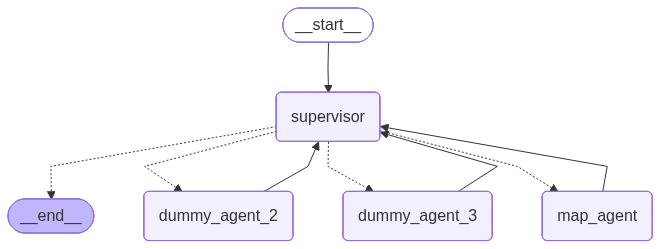

In [73]:
# 그래프 시각화
try:
    from IPython.display import display, Image
    display(Image(supervisor.get_graph().draw_mermaid_png()))
except:
    print("Supervisor 그래프 구조:\n")
    print(supervisor.get_graph().draw_ascii())

## 7. 테스트

테스트 1: Binmap 단일
[노드 supervisor로부터 업데이트]


================================= Tool Message =================================
Name: transfer_to_map_agent

Successfully transferred to map_agent




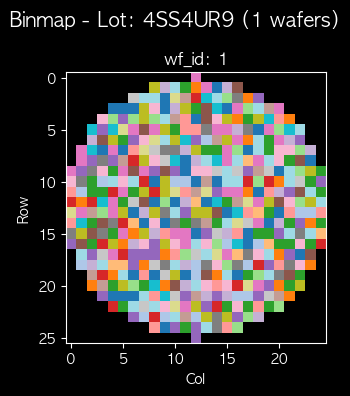

[노드 map_agent로부터 업데이트]


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


[노드 supervisor로부터 업데이트]


================================== Ai Message ==================================
Name: supervisor

lot_id 4SS4UR9, wf_id 1의 binmap 이미지는 다음과 같습니다: ![binmap](binmap_4SS4UR9_20260202_232222.png)




In [55]:
# 테스트 1: Binmap 단일
print("테스트 1: Binmap 단일")
print("="*80)

for chunk in supervisor.stream(
    {"messages": [{"role": "user", "content": "lot_id 4SS4UR9, wf_id 1의 binmap을 보여줘"}]}
):
    pretty_print_messages(chunk, last_message=True)

테스트 2: Binmap 다중
[노드 supervisor로부터 업데이트]


================================= Tool Message =================================
Name: transfer_to_map_agent

Successfully transferred to map_agent




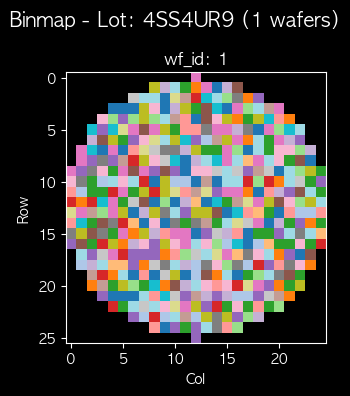

[노드 map_agent로부터 업데이트]


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


[노드 supervisor로부터 업데이트]


================================== Ai Message ==================================
Name: supervisor

lot_id 4SS4UR9의 wf_id 1, 2, 3의 binmap 비교 결과는 다음의 이미지 파일에 저장되었습니다: `binmap_4SS4UR9_20260202_232249.png`. 이 파일을 확인하여 각 웨이퍼의 binmap을 비교해 보세요.




In [57]:
# 테스트 2: Binmap 다중
print("테스트 2: Binmap 다중")
print("="*80)

for chunk in supervisor.stream(
    {"messages": [{"role": "user", "content": "lot_id 4SS4UR9의 wf_id 1, 2, 3 binmap을 비교해줘"}]}
):
    pretty_print_messages(chunk, last_message=True)

테스트 3: Cummap
[노드 supervisor로부터 업데이트]


================================= Tool Message =================================
Name: transfer_to_map_agent

Successfully transferred to map_agent




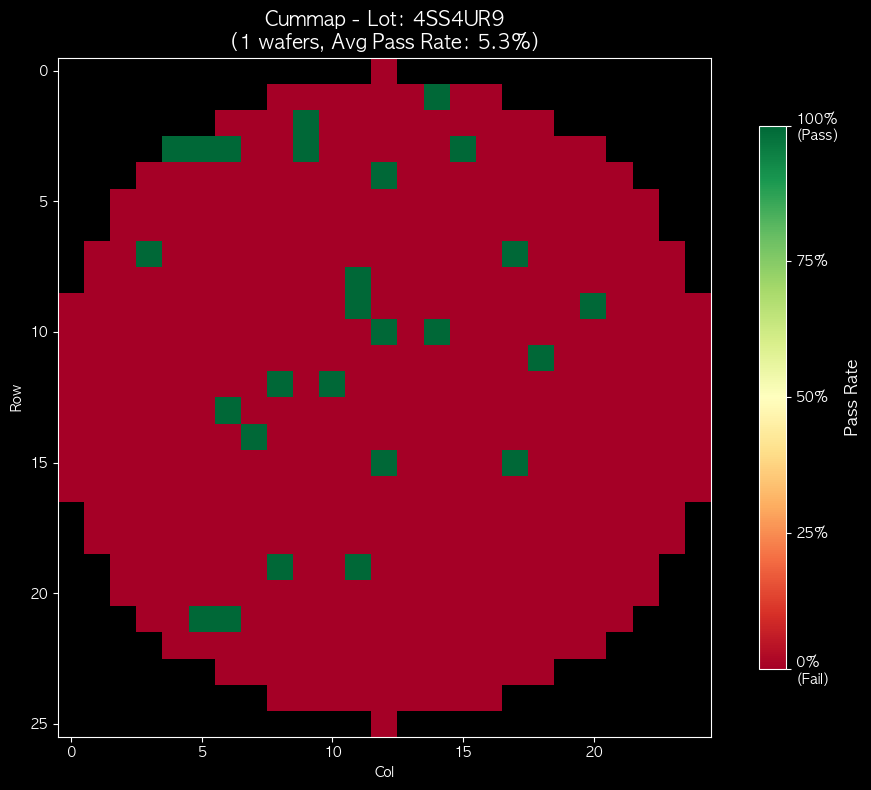

[노드 map_agent로부터 업데이트]


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


[노드 supervisor로부터 업데이트]


================================== Ai Message ==================================
Name: supervisor

cummap 이미지가 생성되었습니다. 평균 Pass Rate는 5.3%입니다. 이미지는 다음 경로에 저장되었습니다: `cummap_4SS4UR9_20260202_231442.png`.




In [ ]:
# 테스트 3: Cummap
print("테스트 3: Cummap")
print("="*80)

for chunk in supervisor.stream(
    {"messages": [{"role": "user", "content": "lot_id 4SS4UR9의 wf_id 1~5 cummap을 그려줘"}]}
):
    pretty_print_messages(chunk, last_message=True)

테스트 4: Binmap + Cummap 둘 다
[노드 supervisor로부터 업데이트]


================================= Tool Message =================================
Name: transfer_to_map_agent

Successfully transferred to map_agent




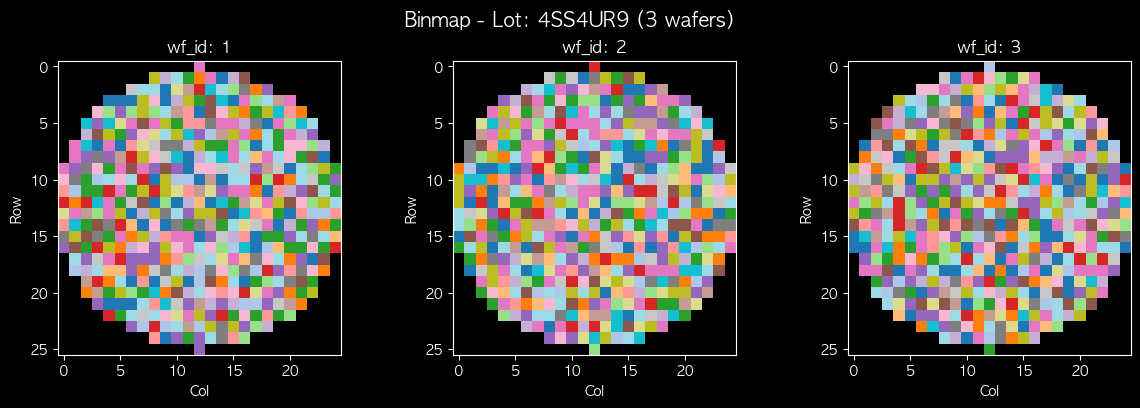

[노드 map_agent로부터 업데이트]


================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor


[노드 supervisor로부터 업데이트]


================================== Ai Message ==================================
Name: supervisor

3개의 웨이퍼에 대한 binmap 비교 결과가 준비되었습니다. 이미지는 다음 경로에 저장되었습니다: `binmap_4SS4UR9_20260202_232409.png`.




In [58]:
# 테스트 4: 둘 다 요청
print("테스트 4: Binmap + Cummap 둘 다")
print("="*80)

for chunk in supervisor.stream(
    {"messages": [{"role": "user", "content": "4SS4UR9.1, 4SSYY23.2, 4SS8JDL.3 binmap을 비교해줘"}]}
):
    pretty_print_messages(chunk, last_message=True)

In [74]:
# 테스트 4: 둘 다 요청
print("테스트 4: Binmap + Cummap 둘 다")
print("="*80)

for chunk in supervisor.stream(
    {"messages": [{"role": "user", "content": "4SS4UR9.1, 4SSYY23.2, 4SS8JDL.3에 대해 binmap과 cummap 둘 다 보여줘"}]}
):
    pretty_print_messages(chunk, last_message=True)

테스트 4: Binmap + Cummap 둘 다


ValueError: {'message': 'Provider returned error', 'code': 408, 'metadata': {'raw': '{ "error": { "code": "Timeout", "message": "The operation was timeout." } }', 'provider_name': 'Azure', 'is_byok': False}}